In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# read
train = pd.read_csv('../data/Task1/train.csv')

In [11]:
# view
train

,date,high,low,momentum_index,beta_indicator,risk_premium,index,volatility_factor,technical_score,oscillator_value,...,open,quant_index,trend_strength,market_sentiment,close,volume,alpha_signal,symbols_Low,symbols_MRO,symbols_ULTA
1,-0.196913,0.240155,0.019485,0.425732,0.423444,0.457001,-1.080382,0.337766,-0.513034,-1.033007,...,-0.112904,1.329208,0.766852,1.136451,-0.496445,2.592941,-0.939444,0,0,0
2,-1.490179,1.138322,-0.419617,-0.103992,-1.069050,0.701019,1.349070,1.529121,-0.965691,-1.184977,...,0.729108,-1.481205,1.983769,-0.030745,-0.525429,4.432505,-0.480651,1,0,0
3,1.208870,-1.994963,-0.790140,-0.627144,-2.065398,-1.588919,-1.342881,-0.432962,0.164071,-1.216836,...,-0.645496,-2.036470,-2.476875,0.532722,-0.462009,-0.531746,0.120062,0,0,1
4,-0.341965,1.619089,-0.537525,-0.751333,0.023851,-1.305679,0.685001,-1.416270,-1.299217,0.912340,...,-0.963171,0.049243,2.061546,-0.344435,0.049613,-0.287021,0.193582,1,0,0
5,-1.602696,-0.055806,-1.236561,-1.343449,0.060810,-1.635265,0.323880,1.147165,-1.842526,0.370447,...,0.636906,-0.759969,0.171091,0.256134,-0.286371,-0.334614,-0.443233,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283080,-0.213181,-1.010069,-0.051539,-0.355718,-0.116353,0.281035,-0.143364,0.259631,-0.232213,-0.239009,...,0.447869,0.038129,-1.663117,-0.264497,0.301701,-0.351478,0.288049,0,0,0
283081,-1.679967,-0.189525,-0.757155,-0.707374,1.531320,-0.469237,1.692544,0.012163,0.492151,-0.350726,...,-0.213693,-0.954426,0.028072,0.129484,-0.321339,-0.138282,1.397489,0,0,1
283082,1.702317,-0.340854,1.102947,1.374319,1.051149,0.975215,0.015490,-1.930084,0.297139,1.674203,...,-1.383100,-0.482244,-0.473379,0.629640,-0.011282,-0.511202,-1.123887,0,1,0
283083,-0.416524,-0.205364,0.159949,0.407796,-0.875425,-0.111798,0.212327,0.982293,0.815353,-1.138752,...,0.529209,-1.043094,-0.041837,1.077739,-0.270948,-0.492111,0.726633,0,0,0


In [ ]:
train.info()
train.describe()

# Preprocess

In [3]:
# drop duplicates
print(train.duplicated().sum())
train.drop_duplicates(inplace=True)

train.isna().sum() / train.index.size * 100
# barely any missing so simply dropping
train.dropna(inplace=True)
train = train[train.date != '0']

20969


In [4]:
train.date = pd.to_datetime(train.date)
# replace raw date by time elapsed from the earliest date
min_date = train.date.min() # will need for testing
train.date = (train.date - min_date).dt.total_seconds()

In [5]:
train.symbols.value_counts()
# one-hot encoding of symbols
train = pd.get_dummies(train, columns=['symbols'], drop_first=True, dtype=int)

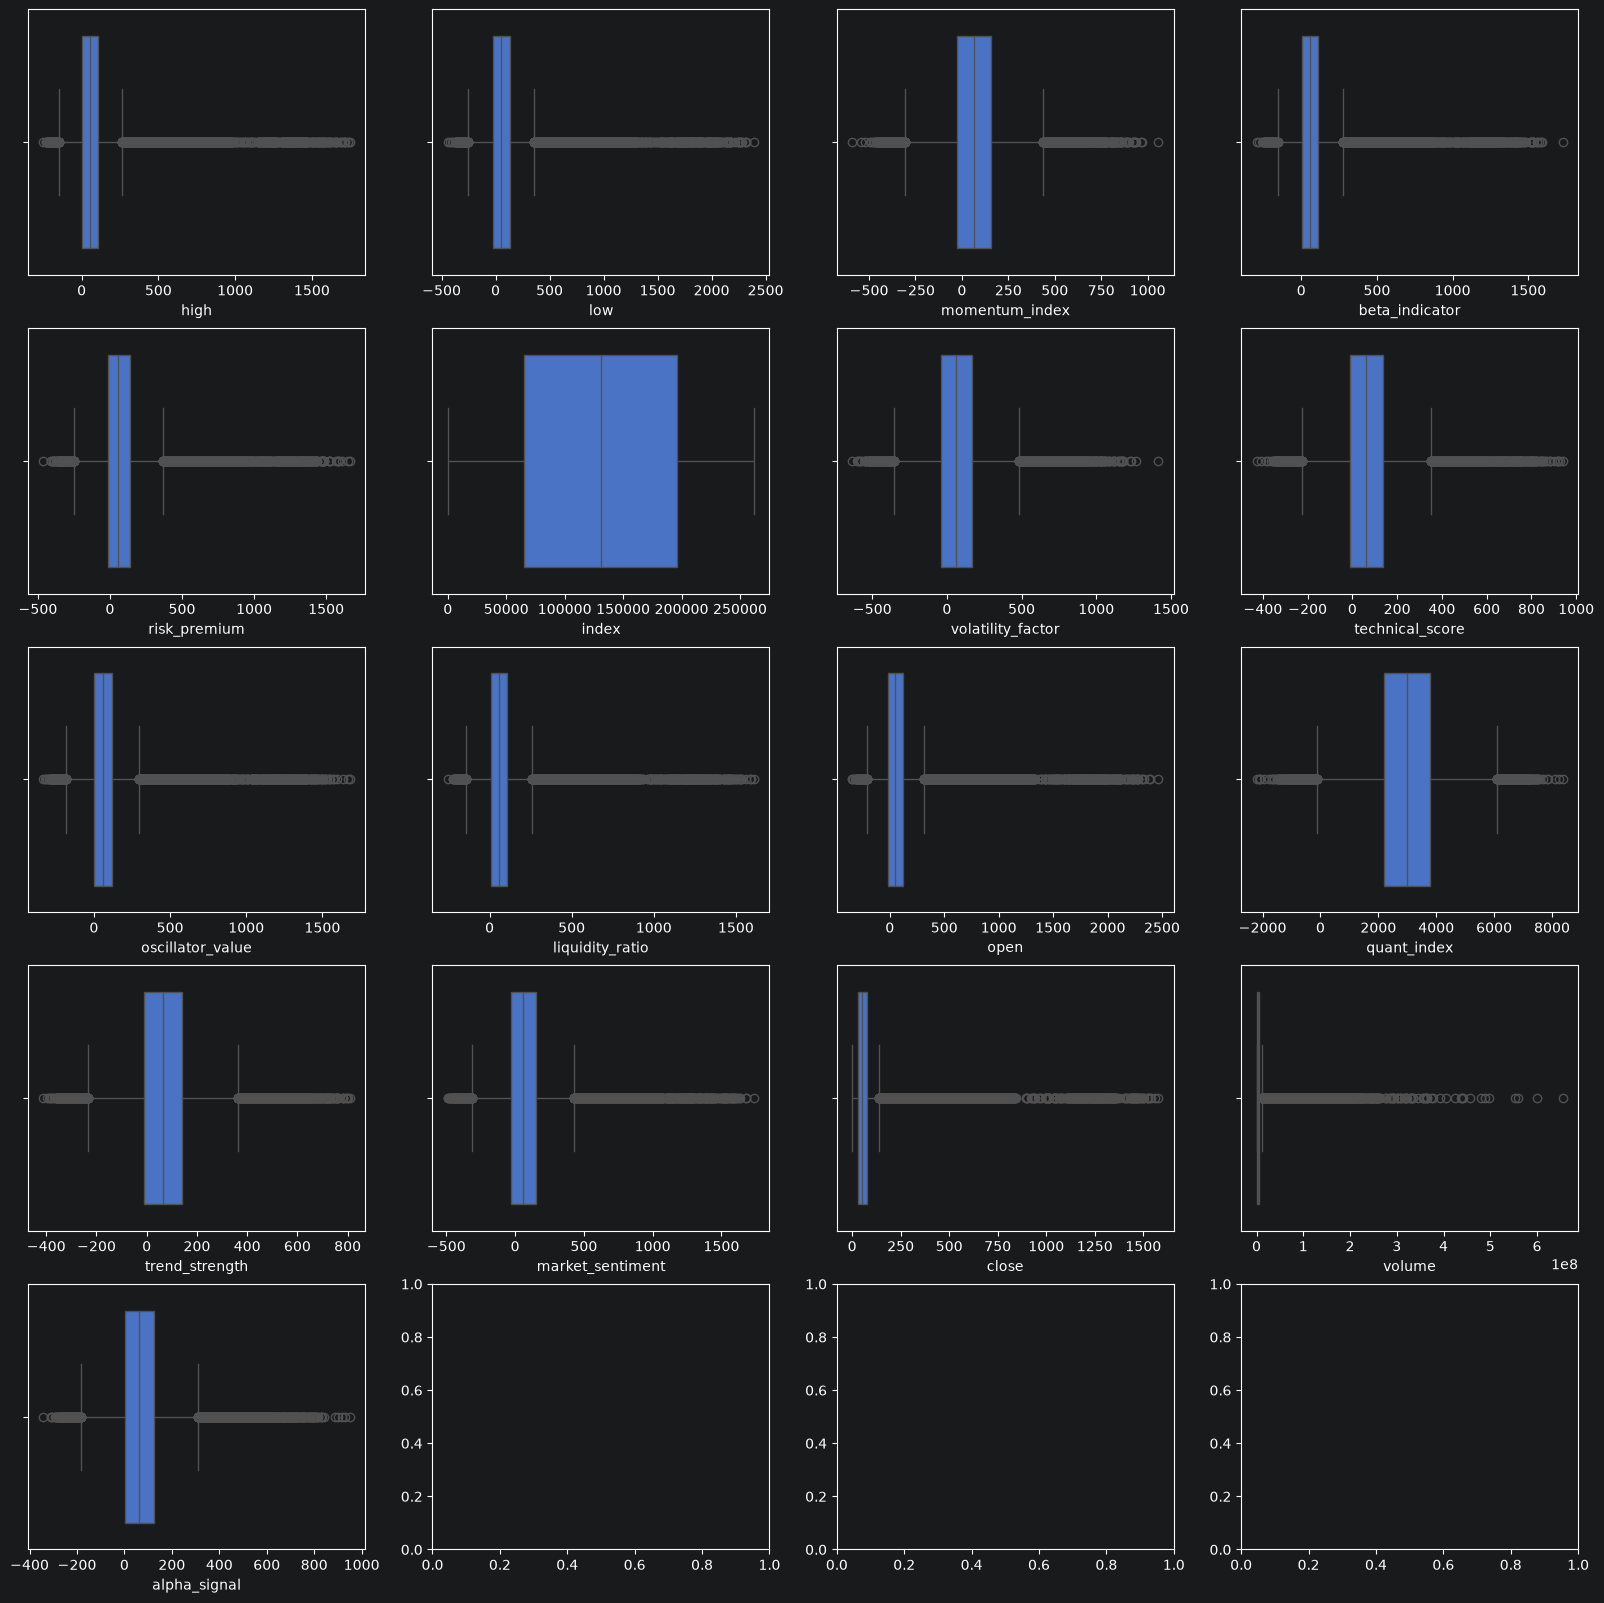

In [6]:
# boxplot to detect outliers
fig, ax = plt.subplots(5, 4, figsize=(20, 20))
for i in range(0, 4):
    sns.boxplot(x=train.iloc[:,i*4+1], ax=ax[i][0])
    sns.boxplot(x=train.iloc[:,i*4+2], ax=ax[i][1])
    sns.boxplot(x=train.iloc[:,i*4+3], ax=ax[i][2])
    sns.boxplot(x=train.iloc[:,i*4+4], ax=ax[i][3])
sns.boxplot(x=train.alpha_signal, ax=ax[4][0])
plt.show()

In [7]:
# outlier treatment
for feature in ['high', 'low', 'beta_indicator', 'risk_premium', 'oscillator_value', 'liquidity_ratio', 'open', 'market_sentiment', 'volume']:
    train[feature] = np.clip(train[feature], *np.percentile(train[feature], [1, 99]))
for feature in ['momentum_index', 'volatility_factor', 'technical_score', 'quant_index', 'trend_strength', 'alpha_signal']:
    q1, q3 = np.percentile(train[feature], [25, 75])
    iqr = q3 - q1
    train[feature] = np.clip(train[feature], q1 - iqr*1.5, q3 + iqr*1.5)

In [8]:
# reserve stats
y_mean, y_std = np.mean(train.close), np.std(train.close)
means = train.describe().T['mean'].iloc[:18]
stds = train.describe().T['std'].iloc[:18]

In [9]:
# feature scaling
def standardize(data, feature):
    data[feature] = (data[feature] - means[feature]) / stds[feature]
for col in train.columns[:18]:
    standardize(train, col)

# Train

In [12]:
def destandardize(y):
    return y * y_std + y_mean

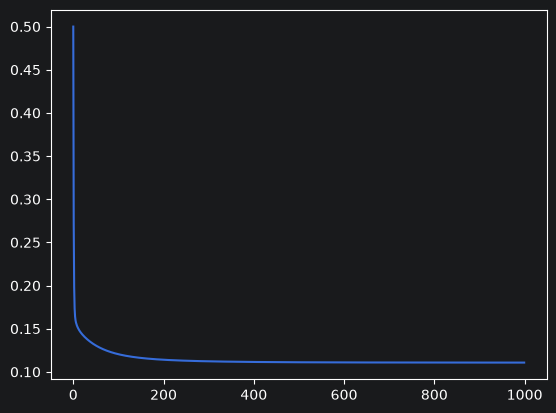

In [13]:
EPOCHS = 1000

x = np.hstack([np.ones((train.index.size, 1)), np.array(train.drop(columns=['close']))])
y = np.array(train[['close']])
weights = np.zeros((x.shape[1], 1))
alpha = 0.1
costs = np.zeros(EPOCHS)
for i in range(EPOCHS):
    hx = np.matmul(x, weights)
    weights -= alpha * np.matmul(x.T, (hx - y)) / x.shape[0]
    costs[i] = np.mean((hx-y)**2) / 2

plt.plot(costs)
plt.show()

# Preprocess Test Dataset

In [14]:
test = pd.read_csv('../data/Task1/test.csv')

In [15]:
test

,index,date,technical_score,liquidity_ratio,trend_strength,risk_premium,alpha_signal,oscillator_value,open,market_sentiment,close,low,volatility_factor,momentum_index,beta_indicator,high,volume,quant_index,symbols
0,143773.0,2015-02-17,106.424626,137.662028,225.081817,-104.681756,52.049226,-49.953411,-11.284320,133.711633,42.099998,9.341813,-11.289493,-17.097228,39.243436,106.520498,9040600.0,3541.208719,Low
1,161481.0,2012-09-20,52.349283,51.568673,-200.005916,-137.976329,95.471376,103.608070,172.322151,63.263396,102.639999,119.482832,162.895026,111.348426,118.035955,-1.941571,1356100.0,1934.283874,HRS
2,98533.0,2011-05-04,199.923028,319.395144,2.539481,-15.303539,27.533335,164.874545,5.420504,170.496216,46.150002,29.394771,6.884014,24.395089,15.830905,20.636255,6866500.0,1067.178832,Low
3,7690.0,2013-03-20,65.088291,60.809487,-113.426257,384.749623,127.020124,257.980333,74.334335,-206.201636,51.862000,61.258867,99.397755,92.205030,123.048043,-20.326080,4552000.0,5141.372712,HRS
4,2352.0,2011-06-24,62.672551,52.797927,140.822204,317.281414,-14.291165,61.454894,24.079310,237.380130,40.790001,63.233695,42.950269,126.080480,-30.874314,71.009360,1387100.0,2292.223342,HRS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177058,119880.0,2016-06-06,147.782185,226.771455,-173.665474,225.895059,72.985590,279.118313,30.382494,208.385979,72.739998,34.127972,1.277406,-32.381731,78.033255,-22.748656,749400.0,4369.158691,Low
177059,103695.0,2012-02-23,-12.040674,-95.314059,-126.770768,54.668867,163.175638,109.390514,83.027346,-42.155276,27.990000,-19.859546,150.298813,-56.191785,147.710063,-50.862863,7850500.0,2760.585483,Low
177060,131933.0,2015-01-12,25.308021,-0.480118,156.067464,362.456604,-25.235138,93.597222,67.651814,36.934865,103.160004,94.151090,7.710359,44.296781,-7.942993,142.844740,1869200.0,3864.159640,HRS
177061,146868.0,2010-02-19,37.110429,-3.668982,113.527158,10.071785,131.853432,-109.098881,-87.508953,-238.444532,17.253334,42.694600,-84.059861,133.933274,109.027113,35.174488,743800.0,4581.825246,Low


In [ ]:
test.info()
test.describe()

In [16]:
# reorder columns
test = test[['date', 'high', 'low', 'momentum_index', 'beta_indicator', 'risk_premium', 'index', 'volatility_factor', 'technical_score', 'oscillator_value',
             'liquidity_ratio', 'open', 'quant_index', 'trend_strength', 'market_sentiment', 'close', 'volume', 'alpha_signal', 'symbols']]

In [17]:
print(test.duplicated().sum())
test.drop_duplicates(inplace=True)

test.isna().sum() / test.index.size * 100
# barely any missing so simply dropping
test.dropna(inplace=True)
test = test[test.date != '0']

6810


In [18]:
test.date = pd.to_datetime(test.date)
# replace raw date by time elapsed from the earliest date
test.date = (test.date - min_date).dt.total_seconds()   # using train's min_date

In [19]:
test.symbols.value_counts()
# one-hot encoding of symbols
test = pd.get_dummies(test, columns=['symbols'], drop_first=True, dtype=int)

In [20]:
# feature scaling
for col in test.columns[:18]:
    standardize(test, col)

# Test

In [ ]:
x = np.hstack([np.ones((test.index.size, 1)), np.array(test.drop(columns=['close']))])
y = np.array(test[['close']])

hx = np.matmul(x, weights)
cost = np.mean((hx-y)**2) / 2
print('Cost function for test dataset =', cost)

r2 = 1 - 2 * cost / np.var(y)
print('Coefficient of determination (measure of accuracy) =', r2)

In [ ]:
import random

# comparing random predicted and actual labels
print('Predicted label\t\tActual label')
for i in [random.randrange(x.shape[0]) for _ in range(100)]:
    hx = np.matmul(x[i], weights)[0]
    print(f'{destandardize(hx):10.0f}\t\t{destandardize(y[i][0]):10.0f}')